1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-live of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

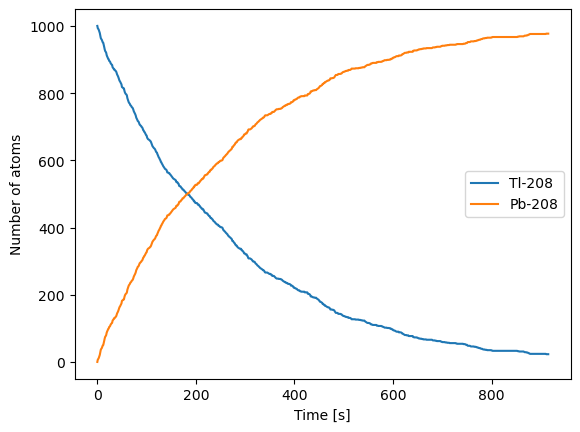

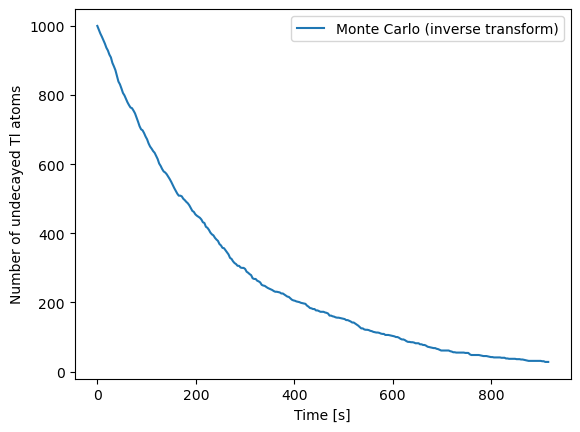

In [1]:
# Total number of Tl atoms that decayed at each step from the Tl sample and are added to the Lead sample.
import numpy as np

N_Tl = 1000
N_Pb = 0
time_step = 1
tau = 3.052 * 60
t = np.arange(0,5 * tau, time_step)

prob = 1 - 2**( -time_step / tau )

Tl_hist = []
Pb_hist = []

for _ in t:
    Tl_hist.append(N_Tl)
    Pb_hist.append(N_Pb)

    # Number of decays in this second.
    decays = np.random.binomial(N_Tl, prob) # Because each Thallium atom has probability " prob " to decay during a 1-second step.

    N_Tl -= decays
    N_Pb += decays

import matplotlib.pyplot as plt

plt.plot(t, Tl_hist, label="Tl-208")
plt.plot(t, Pb_hist, label="Pb-208")
plt.xlabel("Time [s]")
plt.ylabel("Number of atoms")
plt.legend()
plt.show()

# Plot showing the number of atoms that have not decayed as a function of time.

# Inverse transform sampling.
N = 1000
u = np.random.random(N)
# Integrating the expresion given (from 0 to t as it's a CDF), we can see that it's the same as in the first section:
# u = F(t) = " prob ", but now t is not the time step, it will be the decay time of each atom. 
decay_times = -tau * (np.log(u) / np.log(2)) # Remember that: log_2(a) = log(n)/log(a). 

# Time axis for counting survivors.
t = np.linspace(0, 5 * tau, 300)

# Number of undecayed atoms as a function of time.
N_undecayed = [np.sum(decay_times > ti) for ti in t]

# Plot
plt.plot(t, N_undecayed, label="Monte Carlo (inverse transform)")
plt.xlabel("Time [s]")
plt.ylabel("Number of undecayed Tl atoms")
plt.legend()
plt.show()

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [2]:
e = 1.60217663e-19
epsilon_0 = 8.85418782e-12
a0 = 5.29177211e-11
Z = 79
E = 7.7e6 * e
sigma = a0 / 100
n_particles = int(1e6)

import numpy as np

x = np.random.normal(0, sigma, n_particles)
y = np.random.normal(0, sigma, n_particles)
b = np.sqrt((x**2) + (y**2))
mask = b > 0
b = b[mask] # To avoid dividing by 0.

theta = 2 * np.arctan(Z * (e**2) / (2 * np.pi * epsilon_0 * E * b))

bounce = theta > np.pi/2 # This gives an array as [True,False,False,..].
bounce_number = np.sum(bounce) # " np.sum() " interprets True as 1 and False as 0.

percentage = (bounce_number / n_particles) * 100
print(f"Percentage of particles that bounced back: {percentage:.2f}%")

Percentage of particles that bounced back: 0.15%


3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [3]:
# Integral of f(x) between 0 and 2 with the hit/miss method.

import numpy as np

def f(x):
    return (np.sin(1/(x*(2-x))))**2
    
N = int(1e6)

x_samples = np.random.uniform(0, 2, N)
y_samples = np.random.uniform(0, 1, N)
hits = y_samples < f(x_samples)
count = np.sum(hits)

Int = 2 * count / N # Remember that 2 is the area.

from scipy.integrate import quad

integral_value, _ = quad(f, 0.01, 1.99)
print(f"True Integral Value: {integral_value:.10f}")
print(f"Hit/Miss Integral Value: {Int:.10f}")
print (f"relative error: {np.abs(Int - integral_value)/integral_value:.6%}")

# Integral with the mean value method.

I_mean = (2/N) * np.sum(f(x_samples))
error_mean_method = 2 * np.std(f(x_samples)) / np.sqrt(N)

print(f"Mean Integral Value: {I_mean:.10f}")
print (f"relative error: {np.abs(I_mean - integral_value)/integral_value:.6%}")
print(f"Statistical Uncertainty: +/- {error_mean_method:.10f}")

True Integral Value: 1.4414063256
Hit/Miss Integral Value: 1.4512220000
relative error: 0.680979%
Mean Integral Value: 1.4523504464
relative error: 0.759267%
Statistical Uncertainty: +/- 0.0005260732


4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [4]:
# Area of a circle of unit radius integrating the function f(x,y).

N = int(1e6)
V = 4 # Volume of the 2D square [-1, 1] x [-1, 1]

import numpy as np

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
f_values = (x**2 + y**2 <= 1)

I_m1 = (V / N) * np.sum(f_values)
print(f"Area of circle (Integral I): {I_m1:.4f}")

# Generalized result for a 10D sphere.

D = 10
V = 2**(D)
samples = np.random.uniform(-1, 1, size=(D, N))
r_squared = np.sum(samples**2, axis=0) # axis=0: sum over dimensions (rows), giving r^2 for each sampled point.
f_values = r_squared <= 1
I_m2 = (V / N) * np.sum(f_values)

print(f"Area of 10D sphere (Integral I): {I_m2:.4f}")

Area of circle (Integral I): 3.1411
Area of 10D sphere (Integral I): 2.5539


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [5]:
N = int(1e6)

def f(x):
    return (x**(-1/2)) / (np.exp(x) + 1)

# From theory, we can define a PDF as {p(x) = w(x) / [int( w(x) ) from a to b]} (normalized) so I = mean(f(x)/p(x)).
# In this case [int( w(x) ) from a to b] = [int( w(x) ) from 0 to 1] = 2*(1)**0.5 - 2*(0)**0.5 = 2.
def p(x): 
    return 1 / (2 * np.sqrt(x))

# We generate uniform z (CDF of p(x)) and then define x (this generates a grid of points more concentrated on where the integral get most significant values, in this case x = 0).
z = np.random.random(N) # CDF.
x_imp = z**2  # This follows p(x) = 1/(2*sqrt(x)) so z is the integral, z = sqrt(x), and thus x = z**2 so that we can use a uniform distrib. to define the CDF.

I_imp = np.mean(f(x_imp) / p(x_imp))

print(f"Importance Integral Value: {I_imp:.2f}")

Importance Integral Value: 0.84
